# 9 — Combined Backtest Results & Benchmark

This notebook pulls together the results of all four backtests at the chosen
`entry = 1.5 / exit = 0.5` configuration and compares them against a passive
benchmark:

1. **Baseline** — static z-score signal (notebook 6, out-of-sample)
2. **Refined** — dynamic z-score bands + volatility-scaled drawdown control (notebook 7, OOS)
3. **Rolling — baseline** — walk-forward of the baseline signal (notebook 8)
4. **Rolling — refined** — walk-forward of the refined signal (notebook 8)

**Benchmark:** buy-and-hold, equally-weighted (daily-rebalanced) portfolio of every
equity in the cleaned investment universe (33 names: 10 tech + 23 energy/materials).

All series are reconstructed from the saved intermediate dictionaries so this
notebook is self-contained and reproducible after `8_rolling_backtest.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

from src.local_config import *
from src.config import *
from src.backtest import *
from src.bootstrap import *
from src.rolling_backtest import *
from src.drawdown_optimisation import *
from src.refined_trading_signal import *

# Headline strategy config is sourced from src/config.py (single source of truth)
STRAT = f"entry_{ENTRY_Z}_exit_{EXIT_Z}"
print(f"Config: {STRAT} | R={OBS_COV} | cost={TRANSACTION_COST_PER_LEG*1e4:.0f}bps/leg x {TRANSACTION_LEGS} legs")
pd.set_option("display.max_columns", None)

Config: entry_1.5_exit_0.0 | R=1.0 | cost=15bps/leg x 2 legs


## 1. Load saved intermediate data

In [2]:
# Signal dictionaries (baseline)
with open(PROJECT_ROOT / "data/dictionaries/is_results.pkl", "rb") as f:
    is_results = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/oos_results.pkl", "rb") as f:
    oos_results = pickle.load(f)

# Kalman details (for refined + rolling)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_is.pkl", "rb") as f:
    dynamic_details_is = pickle.load(f)
with open(PROJECT_ROOT / "data/dictionaries/dynamic_details_oos.pkl", "rb") as f:
    dynamic_details_oos = pickle.load(f)

# Portfolio weights + pairs
portfolio       = pd.read_csv(PROJECT_ROOT / "data/portfolio")
weights         = portfolio.set_index("pair")["weight"].to_dict()
portfolio_pairs = set(portfolio["pair"])

# Risk-free rate
rf_is   = pd.read_csv(PROJECT_ROOT / "data/rf_is",  index_col=0, parse_dates=True)
rf_oos  = pd.read_csv(PROJECT_ROOT / "data/rf_oos", index_col=0, parse_dates=True)
rf_full = pd.concat([rf_is, rf_oos]).sort_index()

print("Portfolio pairs:", sorted(portfolio_pairs))

Portfolio pairs: ['1818 HK Equity vs 1921 HK Equity', '2386 HK Equity vs 386 HK Equity', '285 HK Equity vs 3690 HK Equity']


## 2. Reconstruct the four strategy return series

Each block mirrors the exact logic of its source notebook so the numbers match.

In [3]:
# --- 1) BASELINE (notebook 6): weighted sum of per-pair strategy returns ---
# Net of 15bps/leg transaction costs charged on each pair's position turnover.
def build_baseline_portfolio(results, strategy_name, weights, obs_cov=OBS_COV):
    pair_rets = {}
    for (pair_name, R), df in results[strategy_name].items():
        if not np.isclose(float(R), obs_cov) or pair_name not in weights:
            continue
        df = compute_strategy_returns(df.copy())
        cost = leg_transaction_costs(df["position"])
        net  = df["strategy_ret"].fillna(0.0) - cost
        pair_rets[pair_name] = net * weights[pair_name]
    return pd.DataFrame(pair_rets).sum(axis=1)

baseline_is_ret  = build_baseline_portfolio(is_results,  STRAT, weights)
baseline_oos_ret = build_baseline_portfolio(oos_results, STRAT, weights)
print("Baseline OOS:", baseline_oos_ret.index[0].date(), "->", baseline_oos_ret.index[-1].date())

Baseline OOS: 2022-10-03 -> 2025-12-31


In [4]:
# --- 2) REFINED (notebook 7): dynamic bands + drawdown-scaled exposure ---
# Drawdown thresholds derived from per-pair volatility of the baseline signal
is_drawdown_values  = drawdown_thresholds(pair_volatility(extractor(is_results)))
oos_drawdown_values = drawdown_thresholds(pair_volatility(extractor(oos_results)))

thr_cols = ["date", "pair", "obs_cov", "reduce_drawdown_threshold", "close_drawdown_threshold"]
drawdown_thresholds_is  = is_drawdown_values[is_drawdown_values["strategy"]  == STRAT][thr_cols]
drawdown_thresholds_oos = oos_drawdown_values[oos_drawdown_values["strategy"] == STRAT][thr_cols]

dd_portfolio_is  = {k: v for k, v in dynamic_details_is.items()  if k[0] in portfolio_pairs}
dd_portfolio_oos = {k: v for k, v in dynamic_details_oos.items() if k[0] in portfolio_pairs}

is_signals_df  = generate_refined_kalman_signals_1(dynamic_details=dd_portfolio_is,  drawdown_thresholds=drawdown_thresholds_is)
oos_signals_df = generate_refined_kalman_signals_1(dynamic_details=dd_portfolio_oos, drawdown_thresholds=drawdown_thresholds_oos)

def aggregate_refined_portfolio(signals_df, weights, obs_cov=OBS_COV):
    f = signals_df[(np.isclose(signals_df["obs_cov"], obs_cov)) & (signals_df["pair"].isin(weights))].copy()
    f["spread_change"] = f.groupby("pair")["spread_t"].diff()
    f["gross_ret"]     = f["active_position"] * f["spread_change"]
    # Net of 15bps/leg transaction costs on each pair's exposure turnover
    f["tc"]            = f.groupby("pair")["active_position"].transform(leg_transaction_costs)
    f["strategy_ret"]  = (f["gross_ret"] - f["tc"]) * f["pair"].map(weights)
    return f.groupby(f.index)["strategy_ret"].sum()

refined_is_ret  = aggregate_refined_portfolio(is_signals_df,  weights)
refined_oos_ret = aggregate_refined_portfolio(oos_signals_df, weights)
print("Refined OOS:", refined_oos_ret.index[0].date(), "->", refined_oos_ret.index[-1].date())

Refined OOS: 2023-06-19 -> 2025-12-31


In [5]:
# --- 3 & 4) ROLLING walk-forward (notebook 8) for baseline and refined signals ---
# Combine IS + OOS Kalman details into one continuous series per pair
dynamic_details_full = {}
for key in dynamic_details_oos:
    is_df_k  = dynamic_details_is.get(key, pd.DataFrame())
    dynamic_details_full[key] = pd.concat([is_df_k, dynamic_details_oos[key]]).sort_index()
dynamic_details_full = {k: v for k, v in dynamic_details_full.items() if k[0] in portfolio_pairs}

rolling_baseline_ret = walk_forward_backtest(
    dynamic_details=dynamic_details_full, weights=weights,
    entry_z=ENTRY_Z, exit_z=EXIT_Z, obs_cov=OBS_COV, is_window=IS_WINDOW, oos_step=OOS_STEP,
)
rolling_refined_ret = walk_forward_refined_backtest(
    dynamic_details=dynamic_details_full, weights=weights,
    obs_cov=OBS_COV, is_window=IS_WINDOW, oos_step=OOS_STEP, exit_z=EXIT_Z,
)
print("Walk-forward range:", rolling_baseline_ret.index[0].date(), "->", rolling_baseline_ret.index[-1].date())

Walk-forward range: 2019-09-20 -> 2025-12-30


## 3. Benchmark — equally-weighted buy-and-hold universe

The `df1/df2` panels used elsewhere are **log-prices** (notebook 1 applies `np.log`),
so they cannot be used for returns. We therefore pull the **raw price levels** from
`data/raw_data/` for the cleaned investment universe (the 33 tickers that survived
data cleaning and form the strategy's opportunity set), take daily simple returns,
and equally weight across all names, rebalanced daily. This turnover-free long-only
portfolio is the passive alternative an investor could hold instead of the strategy.

In [6]:
# Universe = tickers that survived cleaning (columns of the log-price panels)
tech_cols = pd.read_csv(PROJECT_ROOT / "data/df1_is", index_col=0, nrows=0).columns
comm_cols = pd.read_csv(PROJECT_ROOT / "data/df2_is", index_col=0, nrows=0).columns
universe  = list(tech_cols) + list(comm_cols)

# Raw PRICE LEVELS (Bloomberg dates are day-first)
tech_raw = pd.read_csv(PROJECT_ROOT / "data/raw_data/tech.csv",        index_col=0, parse_dates=True, dayfirst=True)
comm_raw = pd.read_csv(PROJECT_ROOT / "data/raw_data/commodities.csv", index_col=0, parse_dates=True, dayfirst=True)
levels   = tech_raw.join(comm_raw, how="outer").sort_index()
levels   = levels[[c for c in universe if c in levels.columns]]

benchmark_ret = levels.pct_change().mean(axis=1).dropna()
benchmark_ret.name = "benchmark"
print(f"Benchmark: {levels.shape[1]} equities | {benchmark_ret.index[0].date()} -> {benchmark_ret.index[-1].date()}")
print(f"Worst / best EW day: {benchmark_ret.min():.4f} / {benchmark_ret.max():.4f}")

Benchmark: 50 equities | 2015-01-02 -> 2025-12-31
Worst / best EW day: -0.1451 / 0.1272


## 4. Consolidated comparison

**Table A** compares everything over the *common out-of-sample window* so all five
lines are judged on identical dates. The rolling strategies are sliced to the OOS
window here purely for a like-for-like comparison against the baseline/refined
static backtests and the benchmark.

All four strategies are **net of transaction costs** (15 bps per leg, 2 legs per pair,
charged on position turnover — see `src/config.py`). The passive buy-and-hold benchmark
is treated as costless, which is the conservative choice (it flatters the benchmark, so
any strategy outperformance is understated). We select the strongest strategy by
**out-of-sample annualised Sharpe** (risk-adjusted return), not raw PnL, since the
strategy is designed to be market-neutral.

In [7]:
OOS_START = baseline_oos_ret.index[0]

def metrics_over(ret, rf=rf_full, start=None, end=None, **kw):
    r = ret.copy()
    if start is not None or end is not None:
        r = r.loc[start:end]
    rf_a = rf.reindex(r.index).ffill() if rf is not None else None
    return performance_metrics(r, rf=rf_a, **kw)

# Strategy return series in the OOS window (rolling variants sliced to OOS)
strat_series = {
    "Baseline (OOS)":     baseline_oos_ret,
    "Refined (OOS)":      refined_oos_ret,
    "Rolling - baseline": rolling_baseline_ret.loc[OOS_START:],
    "Rolling - refined":  rolling_refined_ret.loc[OOS_START:],
}

# Strict common window so all five lines share identical dates (fully like-for-like)
common_start = max(s.dropna().index[0]  for s in strat_series.values())
common_end   = min(s.dropna().index[-1] for s in strat_series.values())
print("Common OOS window:", common_start.date(), "->", common_end.date())

rows = {name: metrics_over(s, start=common_start, end=common_end, bootstrap_ci=True)
        for name, s in strat_series.items()}
rows["Buy & Hold (EW)"] = metrics_over(benchmark_ret, start=common_start, end=common_end, bootstrap_ci=True)
table_a = pd.DataFrame(rows).T
table_a

Common OOS window: 2023-06-19 -> 2025-12-30


,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
Baseline (OOS),0.0566,0.0434,"0.4032 [-0.7069, 1.4687]",32.07,55.14,-24.05,662
Refined (OOS),0.01,-0.0033,"-0.0388 [-1.1506, 1.0676]",0.58,50.33,-26.45,662
Rolling - baseline,0.0648,0.0515,"0.4773 [-0.6554, 1.5540]",39.3,55.59,-23.61,662
Rolling - refined,0.0094,-0.0039,"-0.0359 [-1.1399, 1.0780]",-3.39,52.72,-36.79,662
Buy & Hold (EW),0.1048,0.0916,"0.9426 [-0.2329, 2.1795]",84.74,58.59,-22.88,662


In [8]:
# Pick the best strategy by OOS annualised Sharpe (point estimate)
def sharpe_point(x):
    return float(str(x).split()[0])

strat_rows = table_a.drop("Buy & Hold (EW)")
best = strat_rows["annualised_sharpe"].map(sharpe_point).idxmax()
print(f"Best strategy by OOS Sharpe: {best} "
      f"(Sharpe {strat_rows.loc[best, 'annualised_sharpe']})")
print(f"Benchmark Sharpe over same window: {table_a.loc['Buy & Hold (EW)', 'annualised_sharpe']}")

Best strategy by OOS Sharpe: Rolling - baseline (Sharpe 0.4773  [-0.6554, 1.5540])
Benchmark Sharpe over same window: 0.9426  [-0.2329, 2.1795]


**Table B** puts the two walk-forward strategies over their *full* history against
the benchmark on the same full window — this is the honest, look-ahead-free view of
how the strategy behaves across regimes.

In [9]:
WF_START = rolling_baseline_ret.index[0]
WF_END   = min(rolling_baseline_ret.index[-1], rolling_refined_ret.index[-1])
print("Walk-forward window:", WF_START.date(), "->", WF_END.date())
table_b = pd.DataFrame({
    "Rolling - baseline (full)": metrics_over(rolling_baseline_ret, end=WF_END, bootstrap_ci=True),
    "Rolling - refined (full)":  metrics_over(rolling_refined_ret,  end=WF_END, bootstrap_ci=True),
    "Buy & Hold (EW, full)":     metrics_over(benchmark_ret, start=WF_START, end=WF_END, bootstrap_ci=True),
}).T
table_b

Walk-forward window: 2019-09-20 -> 2025-12-30


,avg_return (%),avg_excess_return (%),annualised_sharpe,total_pnl,hit_rate (%),max_drawdown (%),num_obs
Rolling - baseline (full),0.1848,0.1778,"1.5059 [0.7485, 2.2711]",1449.74,56.53,-23.87,1638
Rolling - refined (full),0.1662,0.1591,"1.3550 [0.5819, 2.0865]",1046.41,55.62,-36.79,1638
"Buy & Hold (EW, full)",0.0876,0.0805,"0.7729 [0.0513, 1.5452]",235.09,56.02,-36.69,1638


## 5. Best strategy vs benchmark — cumulative performance

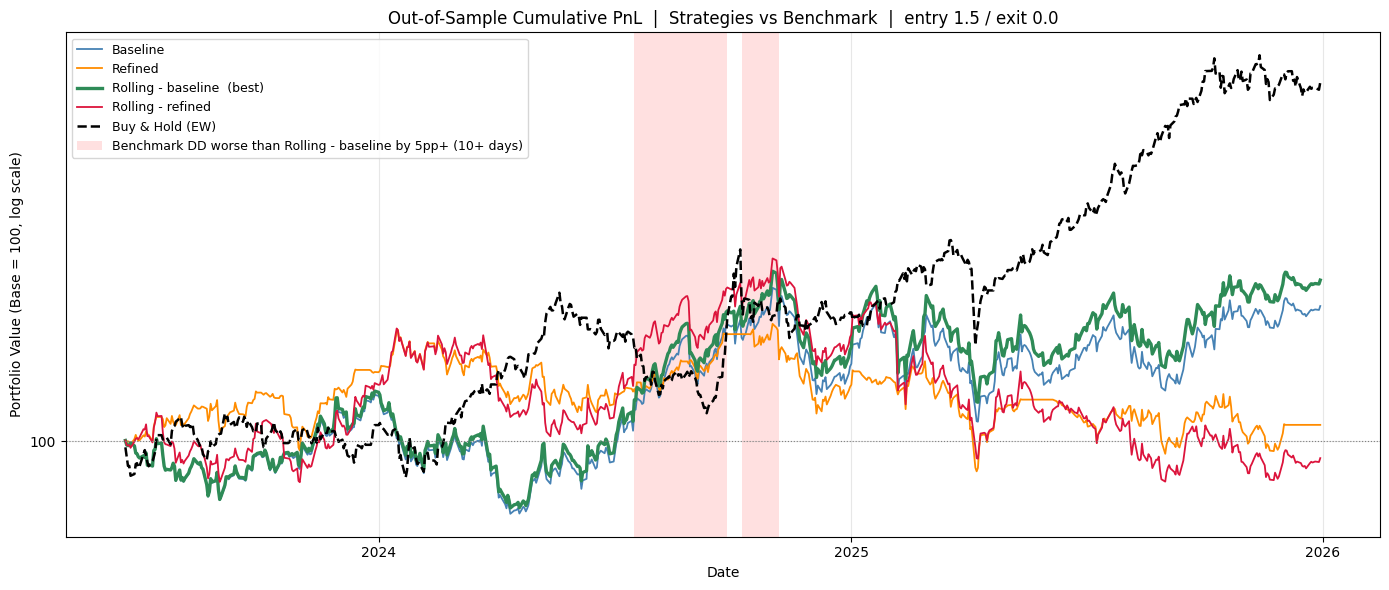

In [10]:
labelmap = {"Baseline (OOS)": "Baseline", "Refined (OOS)": "Refined",
            "Rolling - baseline": "Rolling - baseline", "Rolling - refined": "Rolling - refined"}
colors = {"Baseline (OOS)": "steelblue", "Refined (OOS)": "darkorange",
          "Rolling - baseline": "seagreen", "Rolling - refined": "crimson"}

fig, ax = plt.subplots(figsize=(14, 6))

cum_series = {}
for name, ret in strat_series.items():
    cum = 100 * (1 + ret.loc[common_start:common_end].fillna(0)).cumprod()
    cum_series[name] = cum
    lw = 2.4 if name == best else 1.3
    ax.plot(cum.index, cum, lw=lw, color=colors[name],
            label=f"{labelmap[name]}{'  (best)' if name == best else ''}")

bench_cum = 100 * (1 + benchmark_ret.loc[common_start:common_end].fillna(0)).cumprod()
ax.plot(bench_cum.index, bench_cum, lw=1.8, color="black", ls="--", label="Buy & Hold (EW)")


"""
Highlight periods where the benchmark's running drawdown is materially
worse than the best strategy's, illustrating the drawdown-protection.
A minimum duration filter drops brief single/few-day threshold crossings that are
just noise rather than a genuine sustained divergence.
"""

DD_GAP_THRESHOLD = 5.0   # percentage points; adjust to taste
MIN_SPAN_DAYS    = 10    # minimum consecutive trading days to be shaded

def running_drawdown(cum):
    return (cum - cum.cummax()) / cum.cummax() * 100

bench_dd = running_drawdown(bench_cum)
best_dd  = running_drawdown(cum_series[best])

worse_mask = (bench_dd - best_dd) < -DD_GAP_THRESHOLD  # benchmark DD more negative by > threshold
dates = worse_mask.index

in_span = False
for i, (date, flag) in enumerate(worse_mask.items()):
    if flag and not in_span:
        span_start_idx = i
        in_span = True
    elif not flag and in_span:
        if i - span_start_idx >= MIN_SPAN_DAYS:
            ax.axvspan(dates[span_start_idx], date, color="red", alpha=0.12, lw=0)
        in_span = False
if in_span and len(dates) - span_start_idx >= MIN_SPAN_DAYS:
    ax.axvspan(dates[span_start_idx], dates[-1], color="red", alpha=0.12, lw=0)

ax.axhline(100, color="grey", ls=":", lw=0.8)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.set_title("Out-of-Sample Cumulative PnL  |  Strategies vs Benchmark  |  entry 1.5 / exit 0.0")
ax.set_ylabel("Portfolio Value (Base = 100, log scale)")
ax.set_xlabel("Date")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor="red", alpha=0.12,
                      label=f"Benchmark DD worse than {labelmap[best]} by {DD_GAP_THRESHOLD:.0f}pp+ ({MIN_SPAN_DAYS}+ days)"))
ax.legend(handles=handles, fontsize=9)

ax.grid(True, alpha=0.3)
plt.tight_layout()

save_dir = PROJECT_ROOT / "outputs/combined_results"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(save_dir / "combined_strategies_vs_benchmark_oos.png", dpi=300, bbox_inches="tight")
plt.show()


In [11]:
# Save the consolidated tables for the report
table_a.to_csv(save_dir / "comparison_table_oos.csv")
table_b.to_csv(save_dir / "comparison_table_walkforward.csv")
print("Saved tables + figure to:", save_dir)

Saved tables + figure to: /Users/ivanhung/Documents/GitHub/applied-project-06039211/outputs/combined_results
